In [15]:
import pandas as pd

# Load the CSV file
csv_file = 'CC/CIDDS/Generalisation/unsupervised.csv'
df = pd.read_csv(csv_file)

# Metrics to evaluate
metric_cols = ['F1-Test', 'AUCPR-Test', 'AUCROC-Test']

# Convert metrics to numeric
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors='coerce')

# Filter for PCA rows on the specific test dataset
df_pca = df[(df['model_name'] == 'OCSVM') & (df['Test Dataset'] == 'tabicl_data_NF-UNSW-NB15-v2.npz')]


# Collect top 5 for each metric
TOP_K = 1000
top_rows = pd.DataFrame()
for col in metric_cols:
    # Only proceed if the column exists and isn't all NaNs
    if col in df_pca.columns and not df_pca[col].isna().all():
        top_k = df_pca.nlargest(TOP_K, col)
        top_rows = pd.concat([top_rows, top_k], ignore_index=True)

# Remove duplicates (in case the same row appears in multiple metric top-5s)
top_rows = top_rows.drop_duplicates()

# Save to CSV
out_file = "CC_OCSVM_top5.csv"
top_rows.to_csv(out_file, index=False)



In [100]:
import pandas as pd

# Load the CSV file
csv_file = 'SCARF/NF-CSE-CIC-IDS2018-v2/Downstream/Result_unsupervised.csv'
# csv_file = 'AutoEncoder_Embeddings_Results/CIDDS_unsupervised.csv'
df = pd.read_csv(csv_file)



# Metrics to evaluate
metric_cols = ['Recall-Val', 'AUCPR-Val', 'F1-Val','AUCROC-Val']

# Convert metrics to numeric
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors='coerce')




# Filter for SVM rows
df_svm = df[df['model_name'] == 'PCA']

# Collect top 5 for each metric
top_rows = pd.DataFrame()
for col in metric_cols:
    if not df_svm[col].isnull().all():
        top_k = df_svm.nlargest(5, col)
        top_rows = pd.concat([top_rows, top_k])

# Remove duplicates (in case same row is top in multiple metrics)
top_rows = top_rows.drop_duplicates()

# Save to CSV
top_rows.to_csv("Best_Performer/PCA_cic_scarf.csv", index=False)



In [34]:
import pandas as pd

# Load the CSV file
csv_file = 'AutoEncoder_Embeddings_Results/CIDDS_unsupervised.csv'
df = pd.read_csv(csv_file)

# Metrics to evaluate
metric_cols = ['Recall-Val', 'AUCPR-Val', 'F1-Val','AUCROC-Val']

# Convert metrics to numeric
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors='coerce')

# Filter for IForest rows
df_iforest = df[df['model_name'] == 'IForest']

# --- Filter by Recall-Val ---
# Example: only keep rows where Recall-Val > 0.8
df_iforest_recall = df_iforest[df_iforest['Recall-Test'] < 0.7]

# Get top 5 by Recall-Val
top_recall = df_iforest_recall.nlargest(5, 'Recall-Val')

# Save to CSV
top_recall.to_csv("Best_Performer/test_ae_recall.csv", index=False)


In [374]:

import pandas as pd

# Load the CSV file
csv_file = 'CC_CIDDS.csv'  # Replace with your actual file name
df = pd.read_csv(csv_file)

# Loop through each row and print column-wise
# for index, row in df.iterrows():
#     print(f"\n--- Row {index} ---")
#     for column in df.columns:
#         print(f"{column}: {row[column]}")

df['AUCROC-Test'] = pd.to_numeric(df['Recall-Test'], errors='coerce')
filtered_df = df[(df['Recall-Test'] < 1.0)& (df['model_name'] == 'RF')]

# df['AUCPR-Test'] = pd.to_numeric(df['AUCPR-Test'], errors='coerce')
# filtered_df = df[(df['AUCPR-Test'] > 0.2)& (df['model_name'] == 'OCSVM')]

# df['AUCROC-Test'] = pd.to_numeric(df['AUCROC-Test'], errors='coerce')
# filtered_df = df[(df['AUCROC-Test'] > 0.3)& (df['model_name'] == 'OCSVM')]

# df['F1-Test'] = pd.to_numeric(df['F1-Test'], errors='coerce')
# filtered_df = df[(df['F1-Test'] > 0.9)& (df['model_name'] == 'SVM')]


# df['F1-Micro-Test'] = pd.to_numeric(df['F1-Micro-Test'], errors='coerce')
# filtered_df = df[(df['F1-Micro-Test'] > 0.9)& (df['model_name'] == 'SVM')]

# Drop rows where AUCROC values were NaN
# filtered_df = filtered_df.dropna(subset=['AUCROC-Val', 'AUCROC-Test'], how='all')

# Print filtered rows
print(filtered_df)
# filtered_df.to_csv("filtered_aucpr_svm_models.csv",mode='a', index=False)


# correct this code so it will get all the data from filters and save in the file

KeyError: 'Recall-Test'

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("filtered_aucpr_svm_models.csv")

# Sort by 'Test Dataset' column
df_sorted = df.sort_values(by="Test Dataset")

# Optionally, reset the index
df_sorted = df_sorted.reset_index(drop=True)

# Save the sorted CSV (optional)
df_sorted.to_csv("results_sorted.csv", index=False)

# Display the sorted dataframe
print(df_sorted)


     Unnamed: 0 model_name                                  params  \
0             0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 3, 20)   
1             0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 1, 20)   
2             0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 1, 20)   
3             0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 2, 20)   
4             0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 3, 20)   
..          ...        ...                                     ...   
335           0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 1, 20)   
336           0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 1, 20)   
337           0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 1, 20)   
338           0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 5, 20)   
339           0         RF  ('tabicl_data_NF-UNSW-NB15-v2', 5, 20)   

                             Test Dataset  \
0    scarf_data_NF-CSE-CIC-IDS2018-v2.npz   
1    scarf_data_NF-CSE-CIC-IDS2018-v2.npz   
2    scarf_data_NF-CSE-C

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

import numpy as np

# Confusion matrix format: [[TN, FP], [FN, TP]]
cm = np.array([[2, 87817],
               [2, 179]])
# Convert to double (float64)
cm = cm* 2

print(cm)

# Extract values
TN, FP = cm[0]
FN, TP = cm[1]

# Total samples
total = TN + FP + FN + TP

# Ground truth and predictions (reconstructed from confusion matrix)
y_true = np.array([0] * (TN + FP) + [1] * (FN + TP))
y_pred = np.array([0] * TN + [1] * FP + [0] * FN + [1] * TP)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

# Print results
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"F1 Macro   : {f1_macro:.4f}")
print(f"F1 Micro   : {f1_micro:.4f}")


[[     4 175634]
 [     4    358]]
Accuracy   : 0.0021
Precision  : 0.0020
Recall     : 0.9890
F1 Score   : 0.0041
F1 Macro   : 0.0021
F1 Micro   : 0.0021


In [ ]:
def estimate_confusion_matrix_from_csv(metric_str, total_samples=1200, positive_rate=0.91):
    """
    Estimate a confusion matrix from comma-separated metrics string.
    Input format: "Accuracy,Precision,Recall,F1,F1-Macro,F1-Micro"
    """
    try:
        accuracy, precision, recall, f1, f1_macro, f1_micro = map(float, metric_str.split(','))
    except ValueError:
        raise ValueError("Input must be 6 comma-separated numeric values: Accuracy, Precision, Recall, F1, F1-Macro, F1-Micro")

    # Estimate total positives and negatives
    P = int(positive_rate * total_samples)
    N = total_samples - P

    # Estimate TP and FN from recall
    TP = int(recall * P)
    FN = P - TP

    # Estimate FP from precision
    if precision == 0:
        FP = 0
        TP = 0
    else:
        FP = int((TP / precision) - TP)

    # Estimate TN from accuracy
    TN = int(accuracy * total_samples - TP)

    # Adjust total if rounding error occurs
    estimated_total = TP + TN + FP + FN
    if estimated_total != total_samples:
        TN += total_samples - estimated_total

    # Return confusion matrix
    return [[TN, FP], [FN, TP]]


# --- Example input string ---
metrics_input = "0.0043055555555555555,0.0013096299598751673,0.9215686274509803,0.002615543003422466,0.004302696767233542,0.0043055555555555555"

# --- Estimate confusion matrix ---
cm = estimate_confusion_matrix_from_csv(metrics_input)

# --- Print result ---
print("Estimated Confusion Matrix:")
print(f"[[{cm[0][0]} {cm[0][1]}]\n [{cm[1][0]} {cm[1][1]}]]")


Estimated Confusion Matrix:
[[-767041 767149]
 [86 1006]]


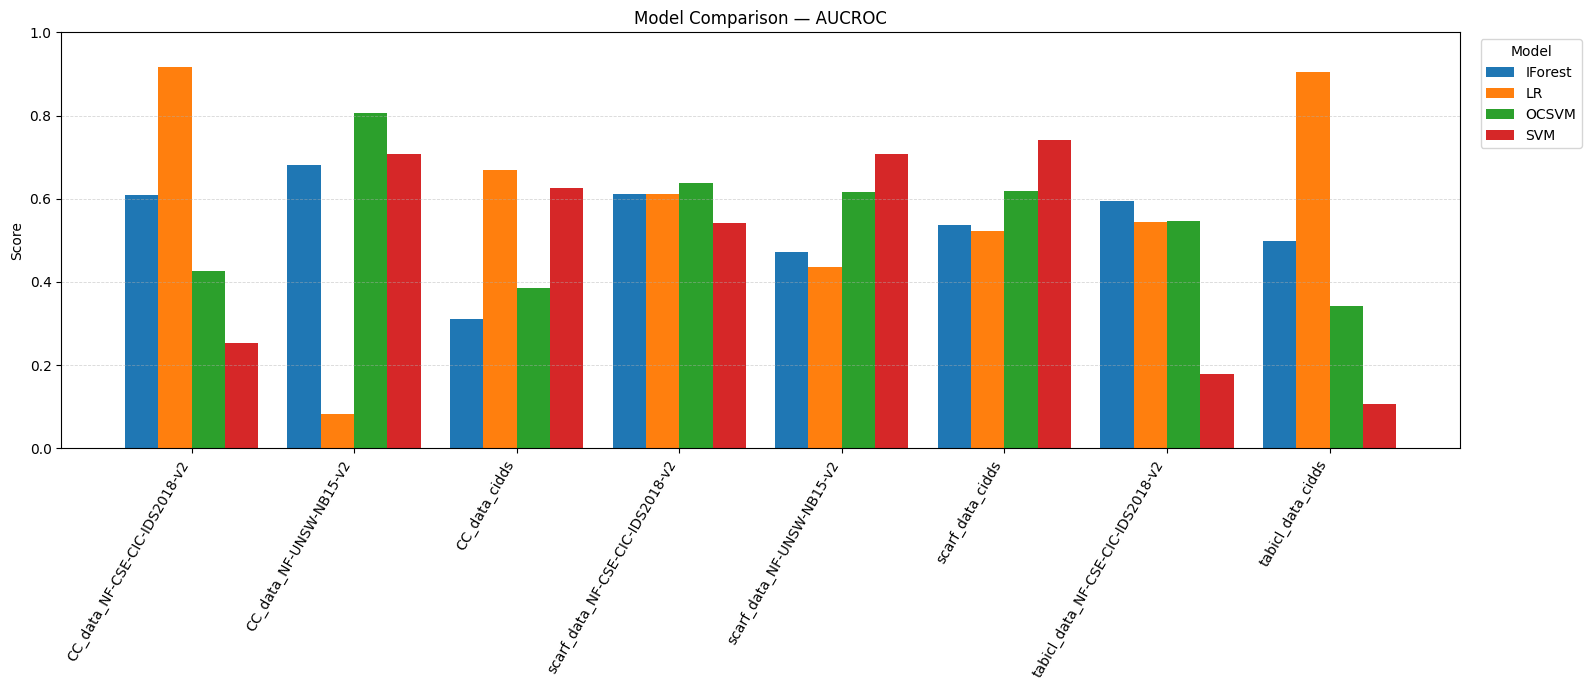

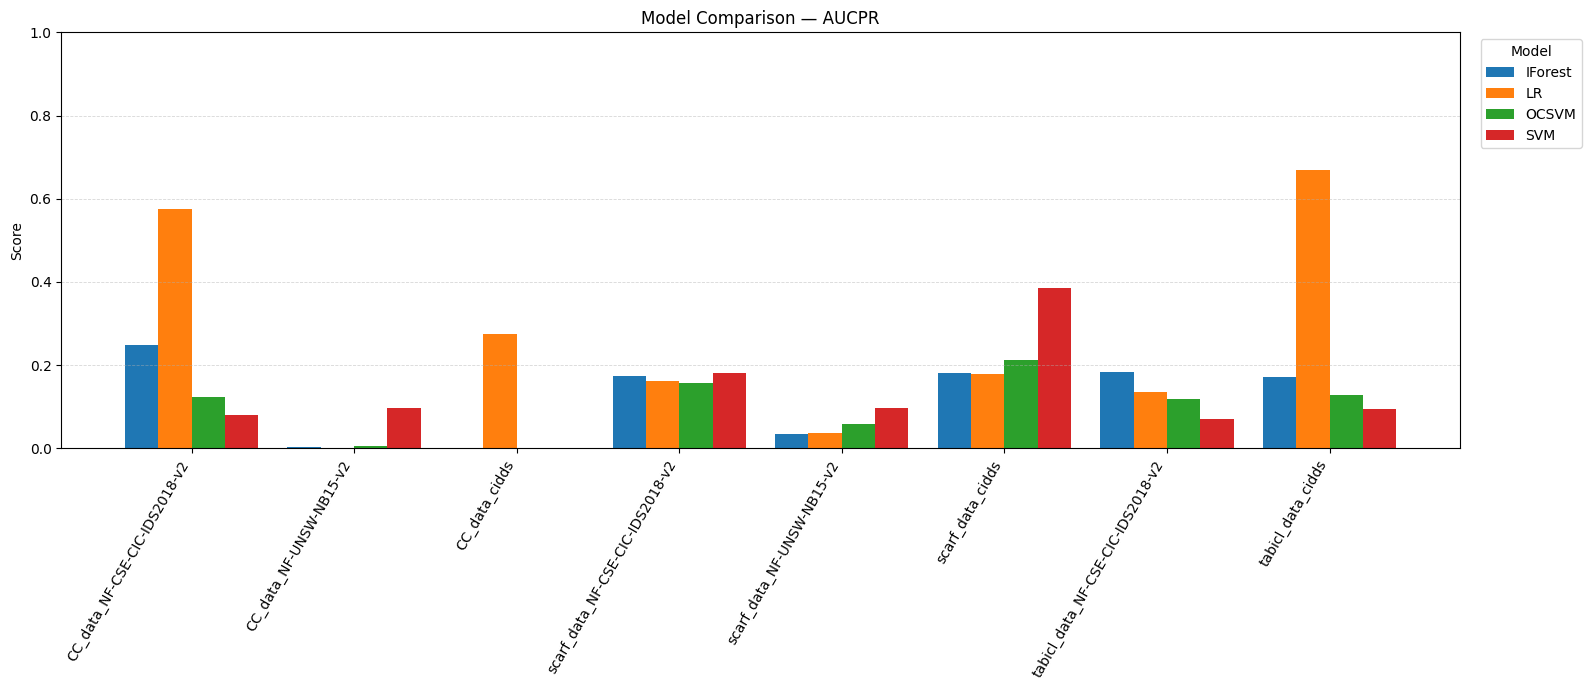

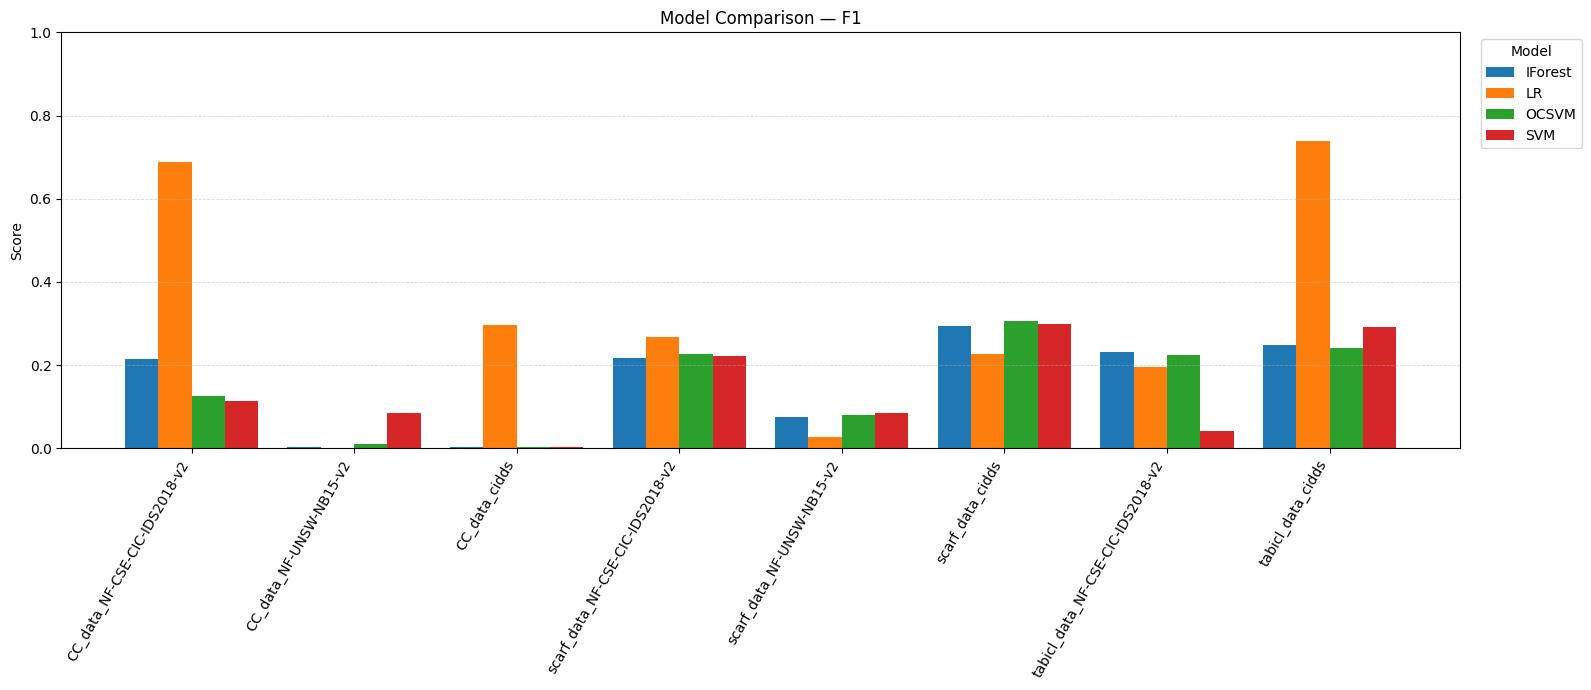

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==== 1) Load your CSV ====
df = pd.read_csv("tabicl_UN.csv")

# ==== 2) (Optional) remove unwanted datasets ==== 
# df = df[~df["Test Dataset"].isin(drop_dsets)].copy()

# ---- Basic sanity checks ----
required_cols = {"Model", "Test Dataset", "AUCROC-Test", "AUCPR-Test", "F1-Test"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {sorted(missing)}")

# ==== 3) Tidy/melt for flexibility ====
melted = df.melt(
    id_vars=["Model", "Test Dataset"],
    value_vars=["AUCROC-Test", "AUCPR-Test", "F1-Test"],
    var_name="Metric",
    value_name="Score"
)

# Order categories for consistent plotting
datasets = sorted(melted["Test Dataset"].unique())
models   = sorted(melted["Model"].unique())
metrics  = ["AUCROC-Test", "AUCPR-Test", "F1-Test"]  # keep a clear, fixed order

# ==== 4) Plot: one figure per metric ====
for metric in metrics:
    subset = melted[melted["Metric"] == metric].copy()
    # Pivot to rows = dataset, columns = model
    pivoted = subset.pivot(index="Test Dataset", columns="Model", values="Score")
    # Ensure consistent order
    pivoted = pivoted.reindex(index=datasets, columns=models)
    # (Optional) keep NaNs for gaps, or fill with 0.0 if you prefer visible bars
    # pivoted = pivoted.fillna(0.0)

    x = np.arange(len(datasets))
    n_models = len(models)
    group_width = 0.82                      # total width reserved for each dataset group
    bar_w = group_width / max(n_models, 1)  # width per bar

    fig, ax = plt.subplots(figsize=(16, 7))

    # Draw one bar per model in each dataset group
    for i, model in enumerate(models):
        heights = pivoted[model].values
        ax.bar(x + (i - (n_models - 1) / 2) * bar_w, heights, width=bar_w, label=model)

    # Formatting
    ax.set_title(f"Model Comparison — {metric.replace('-Test','')}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=60, ha="right")
    ax.set_ylim(0, 1)  # typical for AUROC/AUCPR/F1; adjust if your values differ
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


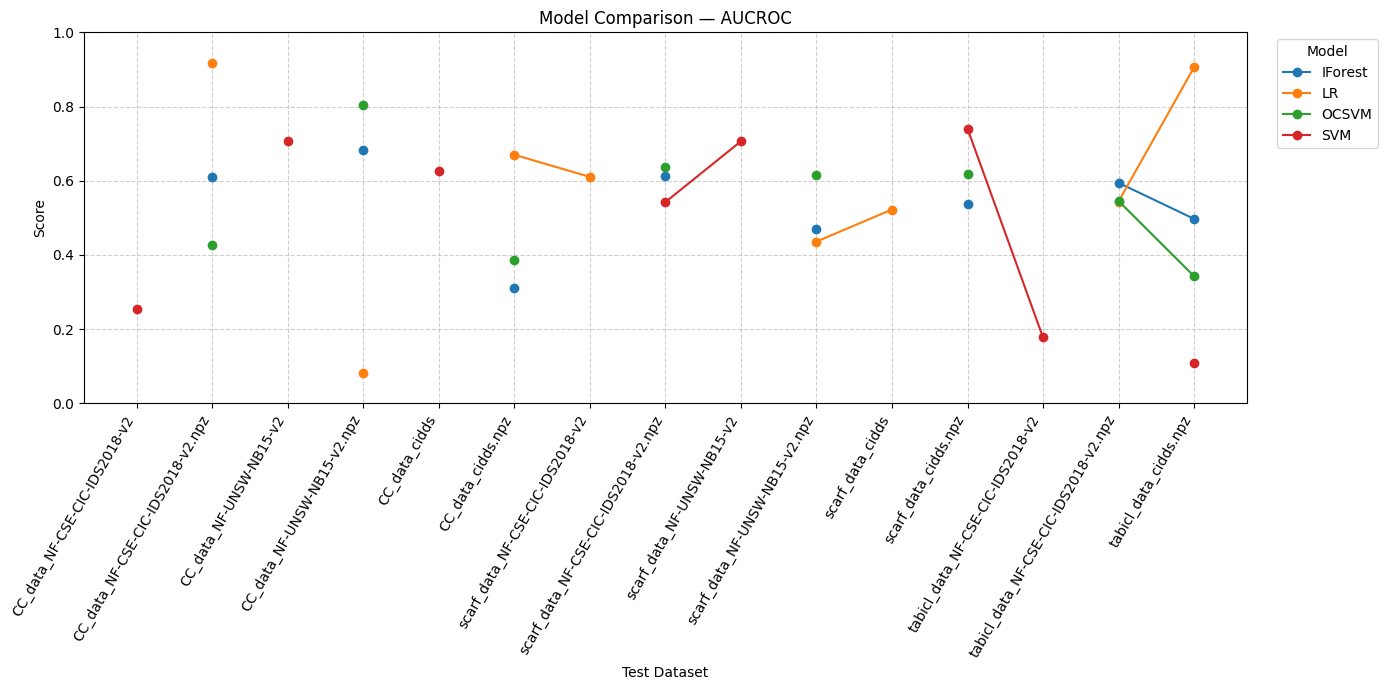

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==== 1) Load your CSV ====
df = pd.read_csv("tabicl_UN.csv")

# ==== 2) (Optional) remove unwanted datasets ====
drop_dsets = {"tabicl_data_cidds1.npz", "tabicl_data_cidds2.npz"}
df = df[~df["Test Dataset"].isin(drop_dsets)].copy()

# ==== 3) Choose metric to plot ====
metric = "AUCROC-Test"   # change to "AUCPR-Test" or "F1-Test" if you like

# Pivot: rows = dataset, columns = model, values = score
pivoted = df.pivot(index="Test Dataset", columns="Model", values=metric)

# Ensure datasets are in consistent order
pivoted = pivoted.sort_index()

# ==== 4) Plot single line graph ====
plt.figure(figsize=(14,7))

for model in pivoted.columns:
    plt.plot(pivoted.index, pivoted[model], marker="o", label=model)

plt.title(f"Model Comparison — {metric.replace('-Test','')}")
plt.xlabel("Test Dataset")
plt.ylabel("Score")
plt.xticks(rotation=60, ha="right")
plt.ylim(0, 1)   # since AUROC/AUCPR/F1 are usually between 0 and 1
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Input and output file paths
input_file = '../bk.csv'    # Change this to your actual file
output_file = 'tabicl_UNSW.csv'

# Columns to keep
columns_to_keep = ['model_name', 'Test Dataset', 'AUCROC-Test', 'AUCPR-Test', 'F1-Test']

# Read only the needed columns from CSV
df = pd.read_csv(input_file, usecols=columns_to_keep)

# Save to new CSV
df.to_csv(output_file, index=False)

print(f"Filtered data saved to {output_file}")


Filtered data saved to tabicl_UNSW.csv


Saved: all_embeddings_models_metrics_bars.png


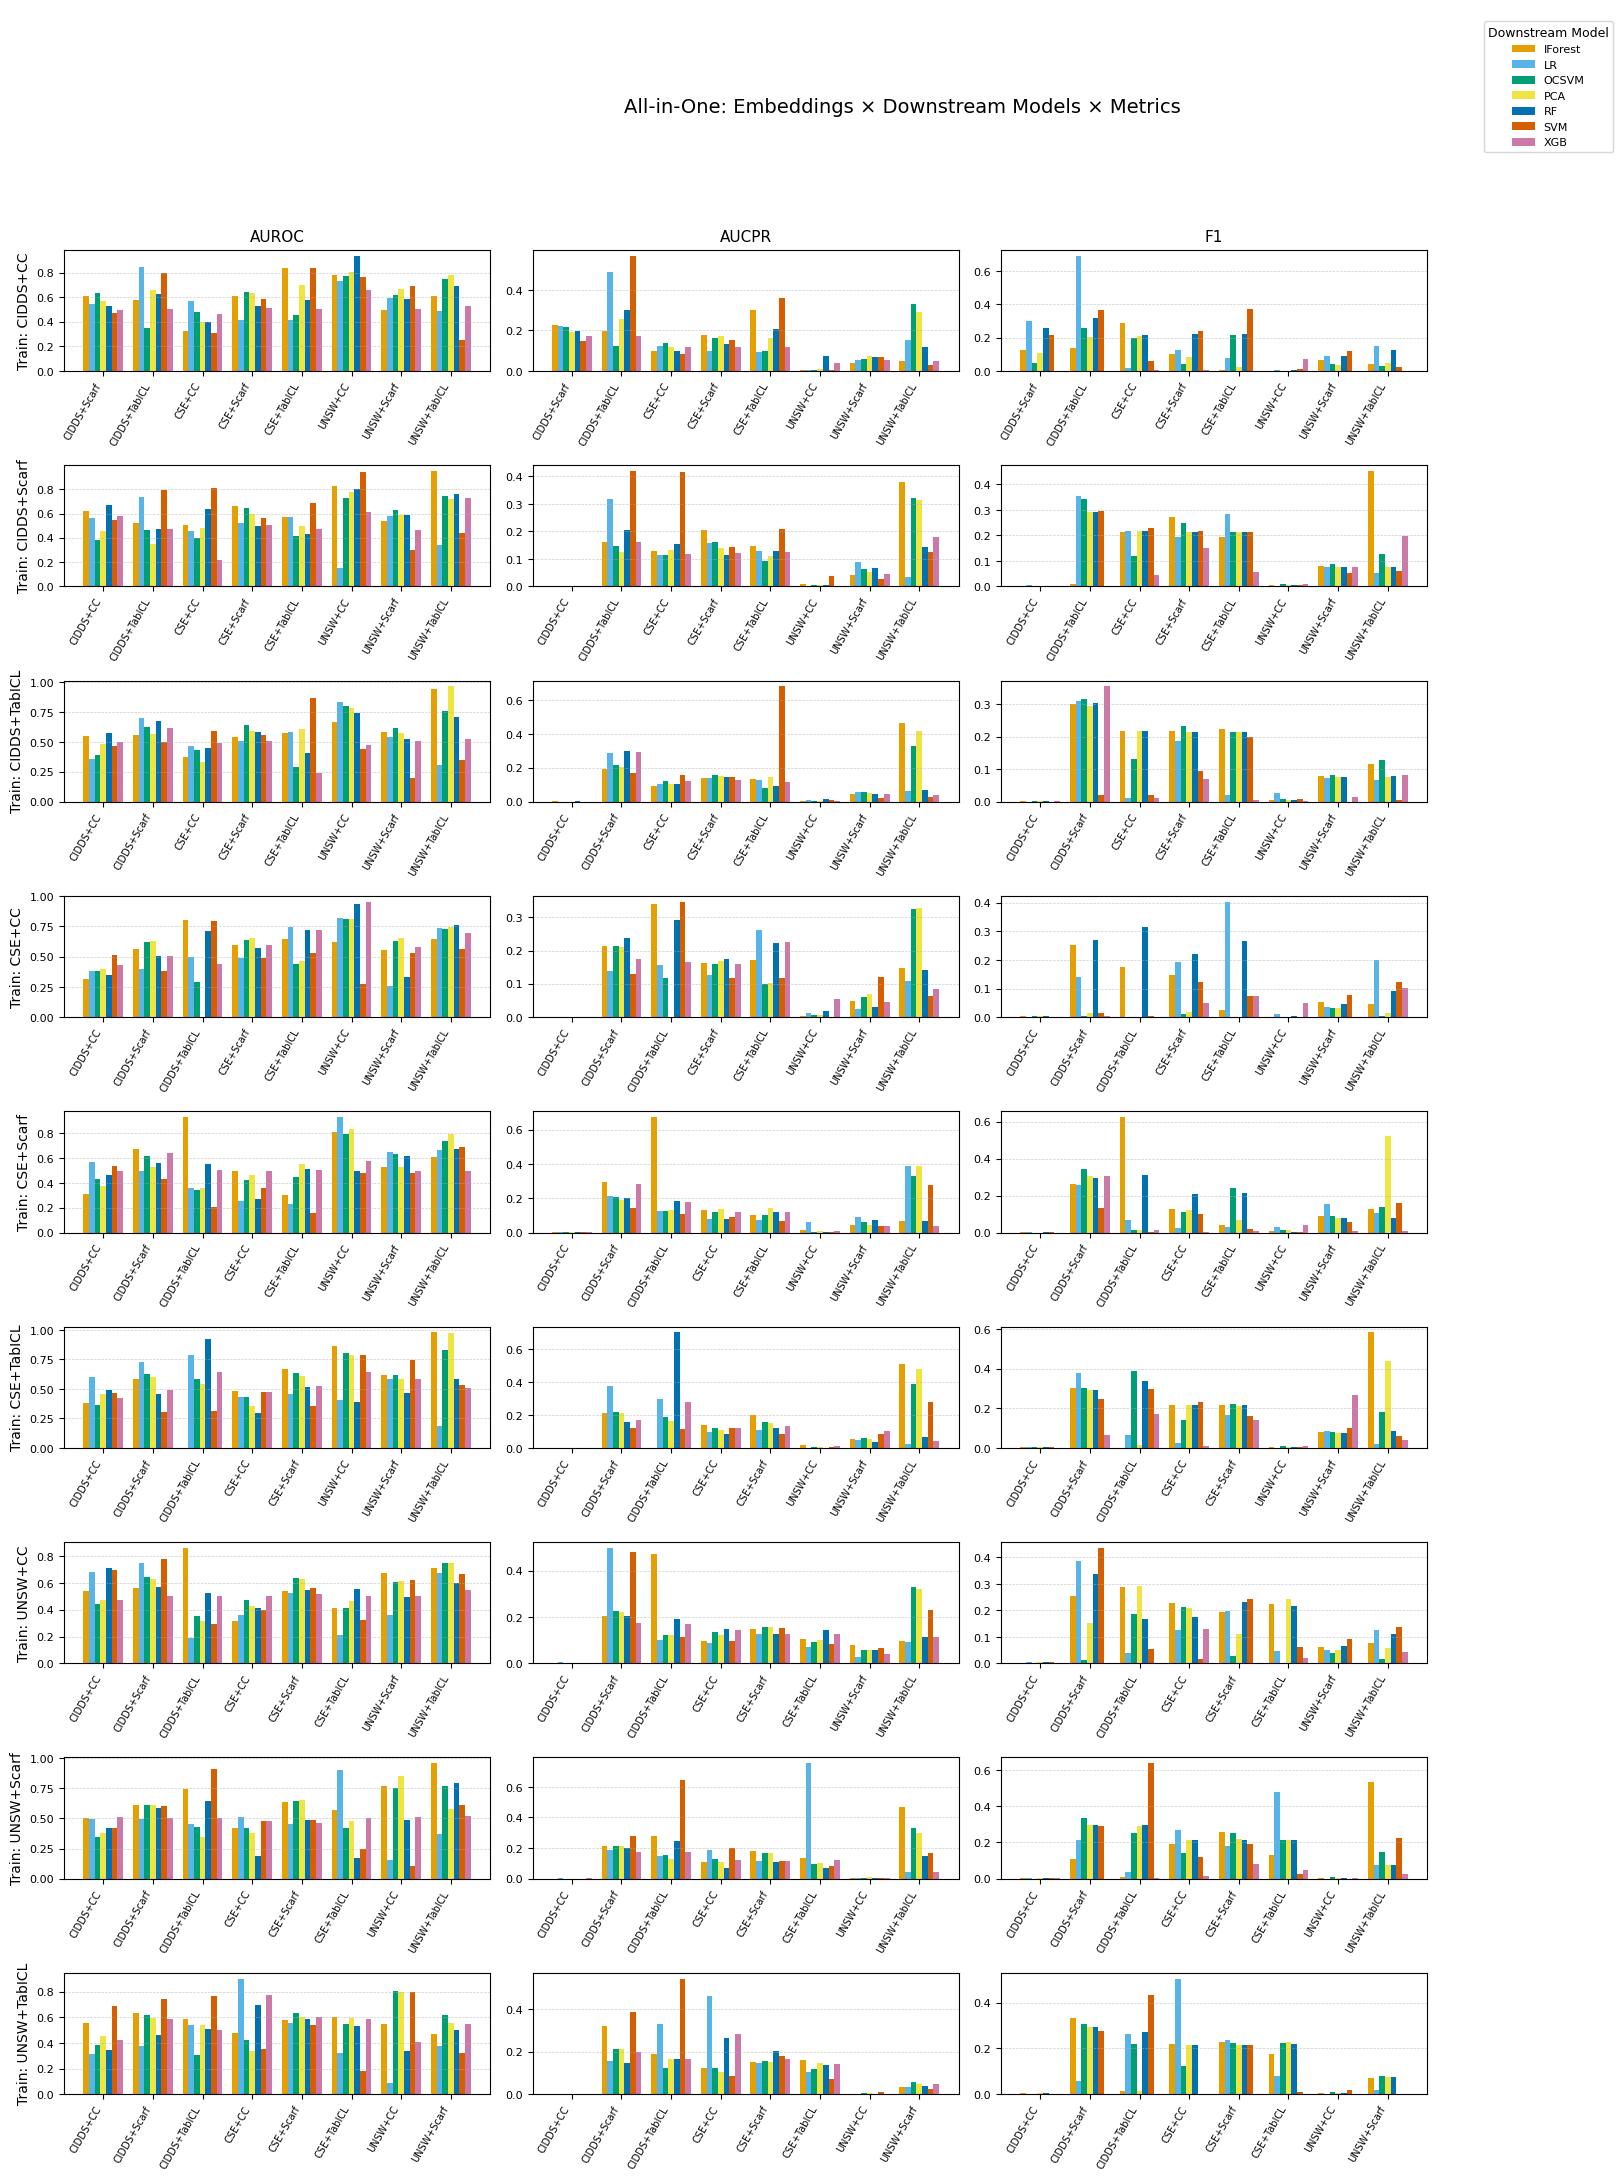

In [ ]:
# all_embeddings_models_metrics_bars_colored.py
# Requires: pandas, matplotlib

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1) Your CSVs (edit paths if needed)
# ------------------------------------------------------------
files = {
    "CC_CIDDS":    "CC_CIDDS.csv",
    "CC_CSE":      "CC_CSE.csv",
    "CC_UNSW":     "CC_UNSW.csv",
    "Scarf_CIDDS": "scarf_cidds.csv",
    "Scarf_CSE":   "scarf_CSE.csv",
    "Scarf_UNSW":  "scarf_UNSW.csv",
    "TabICL_CIDDS":"tabicl_cidds.csv",
    "TabICL_CSE":  "tabicl_CSE.csv",
    "TabICL_UNSW": "tabicl_UNSW.csv",     # if your file is named 'tabicl_UN.csv'
}

# ------------------------------------------------------------
# 2) Color palette — matches your legend
# ------------------------------------------------------------
MODEL_COLORS = {
    "IForest": "#E69F00",  # orange
    "LR":      "#56B4E9",  # light blue
    "OCSVM":   "#009E73",  # green
    "PCA":     "#F0E442",  # yellow
    "RF":      "#0072B2",  # blue
    "SVM":     "#D55E00",  # orange-brown
    "XGB":     "#CC79A7",  # pink
}
LEGEND_ORDER = ["IForest", "LR", "OCSVM", "PCA", "RF", "SVM", "XGB"]
FALLBACK_COLOR = "#999999"

# ------------------------------------------------------------
# 3) Helpers
# ------------------------------------------------------------
def parse_source_to_train(key: str):
    k = key.lower()
    if "cc" in k:
        emb = "CC"
    elif "scarf" in k:
        emb = "Scarf"
    elif "tabicl" in k:
        emb = "TabICL"
    else:
        emb = "Unknown"

    if "cidds" in k:
        ds = "CIDDS"
    elif "cse" in k:
        ds = "CSE"
    elif "unsw" in k or "_un" in k:
        ds = "UNSW"
    else:
        ds = "Unknown"
    return ds, emb

def parse_test_label(lbl: str):
    v = str(lbl).lower()
    if "cidds" in v:
        ds = "CIDDS"
    elif "cse" in v:
        ds = "CSE"
    elif "unsw" in v:
        ds = "UNSW"
    else:
        ds = "Unknown"

    if "cc" in v:
        emb = "CC"
    elif "scarf" in v:
        emb = "Scarf"
    elif "tabicl" in v:
        emb = "TabICL"
    else:
        emb = "Unknown"
    return ds, emb

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # model column may be 'model_name' or 'Model'
    if "model_name" not in df.columns and "Model" in df.columns:
        df.rename(columns={"Model": "model_name"}, inplace=True)

    # metrics may be AUROC/AUCPR/F1 or AUCROC-Test/AUCPR-Test/F1-Test
    if "AUROC" not in df.columns and "AUCROC-Test" in df.columns:
        df.rename(columns={"AUCROC-Test": "AUROC"}, inplace=True)
    if "AUCPR" not in df.columns and "AUCPR-Test" in df.columns:
        df.rename(columns={"AUCPR-Test": "AUCPR"}, inplace=True)
    if "F1" not in df.columns and "F1-Test" in df.columns:
        df.rename(columns={"F1-Test": "F1"}, inplace=True)

    # coerce numeric
    for m in ["AUROC", "AUCPR", "F1"]:
        if m in df.columns:
            df[m] = pd.to_numeric(df[m], errors="coerce")

    needed = ["model_name", "Test Dataset", "AUROC", "AUCPR", "F1"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"CSV missing columns: {missing}")
    return df

# ------------------------------------------------------------
# 4) Load & combine
# ------------------------------------------------------------
frames = []
for key, path in files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}")
    tmp = pd.read_csv(path)
    tmp = normalize_columns(tmp)
    tr_ds, tr_emb = parse_source_to_train(key)
    tmp["TrainDataset"] = tr_ds
    tmp["TrainEmbedding"] = tr_emb
    td = tmp["Test Dataset"].apply(parse_test_label)
    tmp["TestDataset"] = td.apply(lambda t: t[0])
    tmp["TestEmbedding"] = td.apply(lambda t: t[1])
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

# Exclude identical Train (Dataset+Embedding) at Test
mask_same = (df["TrainDataset"] == df["TestDataset"]) & (df["TrainEmbedding"] == df["TestEmbedding"])
df = df[~mask_same].copy()

df["TestLabel"] = df["TestDataset"].astype(str) + "+" + df["TestEmbedding"].astype(str)

# Orders
train_order = [("CIDDS","CC"), ("CIDDS","Scarf"), ("CIDDS","TabICL"),
               ("CSE","CC"),   ("CSE","Scarf"),   ("CSE","TabICL"),
               ("UNSW","CC"),  ("UNSW","Scarf"),  ("UNSW","TabICL")]
test_order = [f"{ds}+{emb}" for ds in ["CIDDS","CSE","UNSW"] for emb in ["CC","Scarf","TabICL"]]
metrics = ["AUROC","AUCPR","F1"]

# ------------------------------------------------------------
# 5) Plot: rows = Train(Dataset+Embedding), cols = metrics
# ------------------------------------------------------------
n_rows, n_cols = len(train_order), len(metrics)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2.2*n_rows + 2), squeeze=False)

for r, (t_ds, t_emb) in enumerate(train_order):
    sub = df[(df["TrainDataset"] == t_ds) & (df["TrainEmbedding"] == t_emb)].copy()
    if sub.empty:
        for c in range(n_cols):
            axes[r, c].axis("off")
        continue

    sub["TestLabel"] = pd.Categorical(sub["TestLabel"], categories=test_order, ordered=True)
    sub = sub.sort_values("TestLabel")
    x_labels = [lbl for lbl in test_order if lbl in sub["TestLabel"].astype(str).unique()]
    x = np.arange(len(x_labels))

    # downstream models present in this subset (preserve your legend order)
    present_models = [m for m in LEGEND_ORDER if m in set(sub["model_name"].dropna())]
    n_models = max(1, len(present_models))
    width = min(0.8 / n_models, 0.15)

    for c, metric in enumerate(metrics):
        ax = axes[r, c]
        for i, m in enumerate(present_models):
            y = []
            for lbl in x_labels:
                v = sub[(sub["TestLabel"].astype(str) == lbl) & (sub["model_name"] == m)][metric].mean()
                y.append(float(v) if pd.notnull(v) else 0.0)
            color = MODEL_COLORS.get(m, FALLBACK_COLOR)
            ax.bar(x + (i - (n_models - 1)/2)*width, y, width, label=m, color=color)

        if r == 0:
            ax.set_title(metric, fontsize=11)
        if c == 0:
            ax.set_ylabel(f"Train: {t_ds}+{t_emb}", fontsize=10)

        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=60, ha="right", fontsize=7)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# One global legend with your exact order (but only those present)
handles = []
labels = []
for m in LEGEND_ORDER:
    if m in set(df["model_name"].dropna()):
        handles.append(Patch(facecolor=MODEL_COLORS.get(m, FALLBACK_COLOR), edgecolor="none"))
        labels.append(m)

fig.legend(handles, labels, title="Downstream Model", fontsize=8, title_fontsize=9,
           loc="upper left", bbox_to_anchor=(0.82, 0.995))

fig.suptitle(
    
    "\n\n\n\nAll-in-One: Embeddings × Downstream Models × Metrics\n",
    fontsize=14, y=0.998
)
plt.tight_layout(rect=[0, 0, 0.8, 0.97])

out_path = "all_embeddings_models_metrics_bars.png"
plt.savefig(out_path, dpi=250)
print(f"Saved: {out_path}")


In [ ]:
unique_labels, counts = np.unique(unique, return_counts=True)
unique_labels

array([0, 1, 2], dtype=object)

In [ ]:
unique_labels, counts = np.unique(unique, return_counts=True)
unique_labels

array([0, 1, 2], dtype=object)

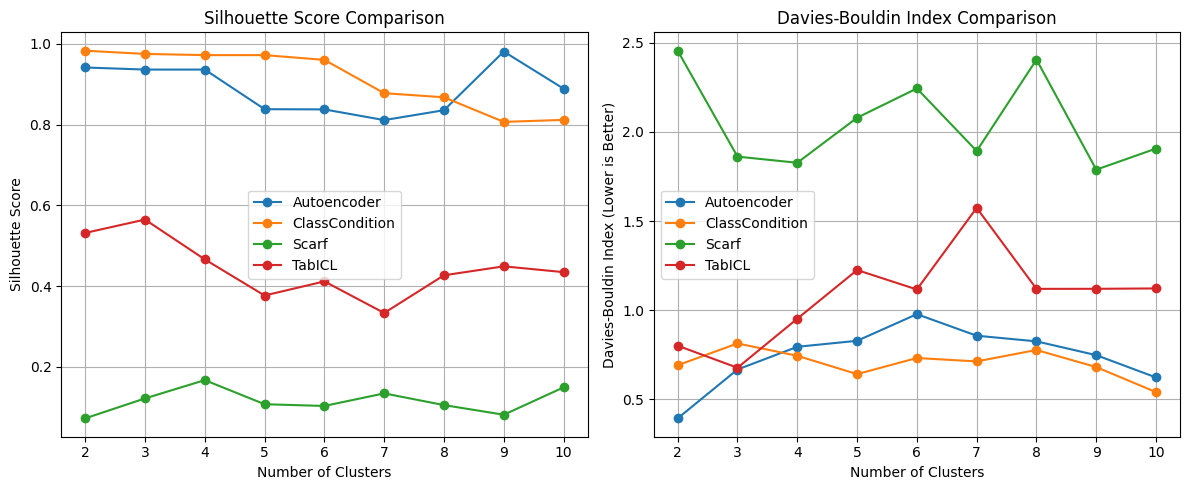

In [389]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths (update with your own file locations if needed)
files = {
    "Autoencoder": "vis/autoencoder_gpu_clustering_scores.csv",
    "ClassCondition": "vis/classcondition_gpu_clustering_scores.csv",
    "Scarf": "vis/scarf_gpu_clustering_scores.csv",
    "TabICL": "vis/tabicl_gpu_clustering_scores.csv",
}

# Read all CSVs into DataFrames
dfs = {name: pd.read_csv(path) for name, path in files.items()}

# Create line charts
plt.figure(figsize=(12,5))

# Silhouette Score Plot
plt.subplot(1,2,1)
for method, df in dfs.items():
    plt.plot(df["n_clusters"], df["silhouette_score"], marker="o", label=method)
plt.title("Silhouette Score Comparison")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)

# Davies-Bouldin Index Plot

plt.subplot(1,2,2)
for method, df in dfs.items():
    plt.plot(df["n_clusters"], df["davies_bouldin_score"], marker="o", label=method)
plt.title("Davies-Bouldin Index Comparison")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index (Lower is Better)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [2]:
import re
import math
import numpy as np
import pandas as pd

# ====================
# Path to your CSV
# ====================
CSV_PATH = "CC/NF-CSE-CIC-IDS2018-v2/OVR/unsupervised.csv"   # <--- put your file path here
CM_COL   = "Confusion-Matrix-Test"               # column containing confusion matrices


# ---------- parsing ----------
def parse_confusion_matrix(text: str) -> np.ndarray:
    """Parse confusion matrix text into a square numpy array."""
    if pd.isna(text):
        raise ValueError("Confusion matrix cell is NaN / empty.")

    s = str(text).strip()
    s = s.replace(",", " ")  # normalize commas to spaces

    # Find rows inside [...]
    row_chunks = re.findall(r"\[([^\]]+)\]", s, flags=re.S)
    rows = []
    for chunk in row_chunks:
        nums = re.findall(r"-?\d+", chunk)
        if nums:
            rows.append([int(x) for x in nums])

    if not rows:
        # fallback: parse all numbers and reshape
        flat = list(map(int, re.findall(r"-?\d+", s)))
        k = int(math.isqrt(len(flat)))
        if k * k != len(flat):
            raise ValueError(f"Cannot reshape {len(flat)} numbers into square matrix.")
        return np.array(flat, dtype=np.int64).reshape(k, k)

    ncols = {len(r) for r in rows}
    if len(ncols) != 1:
        # recover ragged rows by flattening
        flat = [x for r in rows for x in r]
        k = int(math.isqrt(len(flat)))
        if k * k != len(flat):
            raise ValueError(f"Ragged rows {ncols}, total {len(flat)} not square.")
        return np.array(flat, dtype=np.int64).reshape(k, k)

    mat = np.array(rows, dtype=np.int64)
    if mat.shape[0] != mat.shape[1]:
        raise ValueError(f"Matrix not square: {mat.shape}")
    return mat


# ---------- metrics ----------
def safe_div(a, b):
    return a / b if b != 0 else 0.0

def metrics_from_confusion_matrix(cm: np.ndarray) -> dict:
    K = cm.shape[0]
    tp = np.diag(cm).astype(float)
    support = cm.sum(axis=1).astype(float)   # true per class
    pred_totals = cm.sum(axis=0).astype(float)
    total = cm.sum()

    fn = support - tp
    fp = pred_totals - tp

    precision = np.array([safe_div(tp[i], tp[i] + fp[i]) for i in range(K)])
    recall    = np.array([safe_div(tp[i], tp[i] + fn[i]) for i in range(K)])
    f1        = np.array([safe_div(2*precision[i]*recall[i], precision[i]+recall[i])
                          if precision[i]+recall[i] > 0 else 0.0
                          for i in range(K)])

    accuracy = safe_div(tp.sum(), total)
    macro_f1 = float(np.mean(f1))
    weighted_f1 = float(np.sum(f1 * (support/total))) if total > 0 else 0.0
    micro_f1 = accuracy  # for single-label multiclass, micro == accuracy

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "weighted_f1": weighted_f1,
        "per_class_precision": precision.tolist(),
        "per_class_recall": recall.tolist(),
        "per_class_f1": f1.tolist(),
        "per_class_support": support.astype(int).tolist(),
        "num_classes": K,
        "total_samples": int(total),
    }


# ---------- main ----------
def compute_metrics(csv_path=CSV_PATH, matrix_col=CM_COL):
    df = pd.read_csv(csv_path, engine="python")
    results = []
    for idx, row in df.iterrows():
        info = {c: row[c] for c in df.columns if c in ["model_name", "params", "config","AUCROC-Val","AUCPR-Val"]}
        try:
            cm = parse_confusion_matrix(row[matrix_col])
            m = metrics_from_confusion_matrix(cm)
            results.append({**info, **m})
        except Exception as e:
            results.append({**info, "error": str(e)})

    return pd.DataFrame(results)


# ====================
# Run
# ====================
res = compute_metrics()
print(res.head())        # preview
res.to_csv("REP_OVR/CC_OVR_Results.csv", index=False)
print("Saved metrics_output.csv")


  model_name                                   params  \
0    IForest  ('cc_multi_data_NF-CSE-CIC-IDS2018', 1)   
1    IForest  ('cc_multi_data_NF-CSE-CIC-IDS2018', 1)   
2    IForest  ('cc_multi_data_NF-CSE-CIC-IDS2018', 1)   
3    IForest  ('cc_multi_data_NF-CSE-CIC-IDS2018', 1)   
4    IForest  ('cc_multi_data_NF-CSE-CIC-IDS2018', 1)   

                                              config  AUCROC-Val  AUCPR-Val  \
0  {'n_estimators': 10, 'max_samples': 1, 'max_fe...         NaN   0.066667   
1  {'n_estimators': 10, 'max_samples': 1, 'max_fe...         NaN   0.066667   
2  {'n_estimators': 10, 'max_samples': 1, 'max_fe...         NaN   0.066667   
3  {'n_estimators': 10, 'max_samples': 1, 'max_fe...         NaN   0.066667   
4  {'n_estimators': 10, 'max_samples': 1, 'max_fe...         NaN   0.066667   

   accuracy  macro_f1  micro_f1  weighted_f1  \
0  0.879167   0.06238  0.879167     0.822635   
1  0.879167   0.06238  0.879167     0.822635   
2  0.879167   0.06238  0.879167     0.